In [1]:
import os
os.chdir("/nfshome/narjis")

In [85]:
import h5py
import numpy as np
h5_path = "Downloads/brightfield_particles.hdf5"
with h5py.File(h5_path, "r") as h5_file:
    data = np.copy(h5_file["data"]).astype(np.float32)
    labels = np.copy(h5_file["labels"])

In [3]:
import torch
def contrast_from_middle_rows(images: torch.Tensor,n_rows=2) -> torch.Tensor:
    """
    Compute standard deviation (RMS contrast) from the 4 middle rows of each image in a batch.
    
    Args:
        images: Tensor of shape (B, C, H, W)
    
    Returns:
        Tensor of shape (B,) with contrast values.
    """
    B, C, H, W = images.shape
    mid = H // 2
    rows = images[:, :, mid - n_rows:mid + n_rows, :]  # (B, C, 4, W)

    gray = rows[:,0,:,:]  # Convert to grayscale: (B, 4, W)
    contrast = gray.std(dim=(1, 2))  # Compute std over height and width

    return contrast  # shape: (B,)

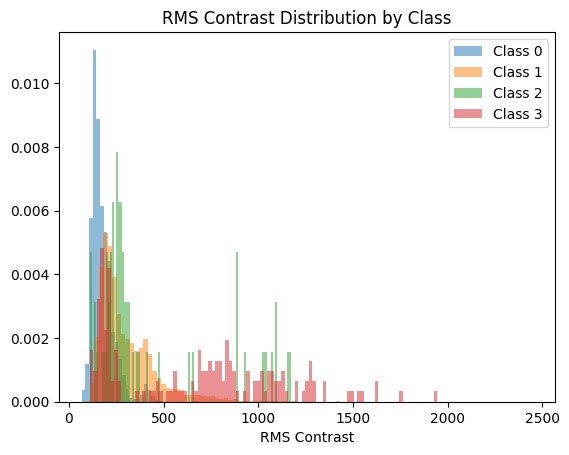

In [86]:
images_0 = data[labels == 0]  # Ensure shape is (B, C, H, W)
images_1 = data[labels == 1]  # Ensure shape is (B, C, H, W)
images_2 = data[labels == 2]  # Ensure shape is (B, C, H, W)
images_3 = data[labels == 3]  # Ensure shape is (B, C, H, W)
images_0 = torch.tensor(images_0, dtype=torch.float32).unsqueeze(1)
images_1 = torch.tensor(images_1, dtype=torch.float32).unsqueeze(1)
images_2 = torch.tensor(images_2, dtype=torch.float32).unsqueeze(1)
images_3 = torch.tensor(images_3, dtype=torch.float32).unsqueeze(1)
contrast_0 = contrast_from_middle_rows(images_0)
contrast_1 = contrast_from_middle_rows(images_1)
contrast_2 = contrast_from_middle_rows(images_2)
contrast_3 = contrast_from_middle_rows(images_3)
import matplotlib.pyplot as plt
plt.hist(contrast_0.numpy(), bins=100, alpha=0.5, label='Class 0',density=True)
plt.hist(contrast_1.numpy(), bins=100, alpha=0.5, label='Class 1',density=True)
plt.hist(contrast_2.numpy(), bins=100, alpha=0.5, label='Class 2',density=True)
plt.hist(contrast_3.numpy(), bins=100, alpha=0.5, label='Class 3',density=True)
plt.xlabel('RMS Contrast')
plt.title('RMS Contrast Distribution by Class')
plt.legend()
plt.savefig("rms_contrast_distribution.png")
plt.show()

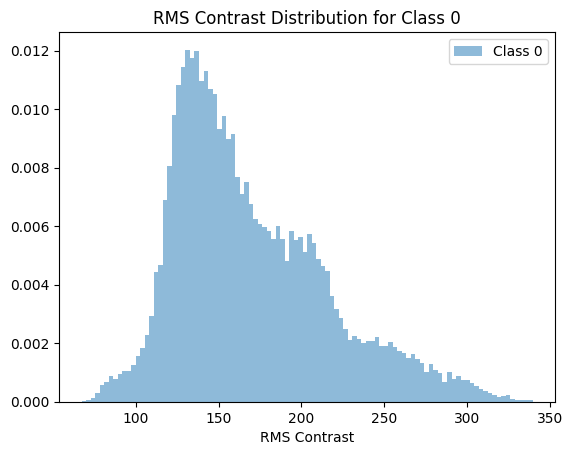

In [30]:
a=(contrast_0-contrast_0.mean())+76
plt.hist(contrast_0[contrast_0<340], bins=100, alpha=0.5, label='Class 0',density=True)
plt.xlabel('RMS Contrast')
plt.title('RMS Contrast Distribution for Class 0')
plt.legend()
plt.show()

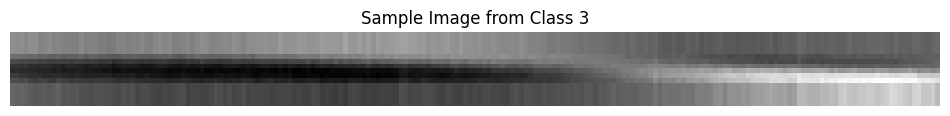

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.imshow(images_3[150, :, :], cmap='gray')
ax.set_title('Sample Image from Class 3')
ax.axis('off')
plt.show()


In [10]:
a=torch.tensor(images_3[0, :, :], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
b=torch.tensor(images_3[100, :, :], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
c= torch.tensor(images_3[150, :, :], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
a,b,c= contrast_from_middle_rows(a,n_rows=2), contrast_from_middle_rows(b,n_rows=2), contrast_from_middle_rows(c,n_rows=2)
print(a,b,c)

tensor([114.6517]) tensor([766.6476]) tensor([1100.8173])


In [51]:
data.shape

(41350, 16, 201)

In [91]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# # Assuming you have 4 images (grayscale) as numpy arrays of shape (h, w)
# # Example: image1, image2, image3, image4
# images = [images_1, images_2, images_3, images_0]
# all_pixels = np.concatenate([image.flatten(start_dim=1).numpy() for image in images])
# kmeans = KMeans(n_clusters=4, random_state=42)
# labels = kmeans.fit_predict(all_pixels)

In [96]:
X=data.reshape(data.shape[0], -1)
X = (X-X.mean())/ X.std()  # Normalize the data
kmeans = KMeans(n_clusters=4, random_state=1)
labels = kmeans.fit_predict(X)

In [97]:
uniques, counts = np.unique(labels, return_counts=True)

In [98]:
counts

array([ 9208, 12075, 11471,  8596])

In [95]:
uniques

array([0, 1, 2, 3], dtype=int32)

In [12]:
# import numpy as np
# from sklearn.cluster import KMeans
# import matplotlib.pyplot as plt

# # Assuming you have 4 images (grayscale) as numpy arrays of shape (h, w)
# # Example: image1, image2, image3, image4
# images = [images_1, images_2, images_3, images_0]

# # Stack all images into a single array of shape (4*h*w,)
# all_pixels = np.concatenate([img.flatten() for img in images])

# # Reshape for KMeans: shape (num_pixels, 1)
# X = all_pixels.reshape(-1, 1)

# # Run KMeans
# kmeans = KMeans(n_clusters=4, random_state=42)
# labels = kmeans.fit_predict(X)

# # Now reshape labels back into the original image shapes
# h, w = images[0].shape
# clustered_images = []
# start = 0

# for img in images:
#     size = img.size
#     clustered = labels[start:start+size].reshape(img.shape)
#     clustered_images.append(clustered)
#     start += size

# # Optional: visualize the result
# for i, clustered_img in enumerate(clustered_images):
#     plt.subplot(2, 2, i+1)
#     plt.imshow(clustered_img, cmap='tab10')
#     plt.title(f"Clustered Image {i+1}")
#     plt.axis('off')

# plt.tight_layout()
# plt.show()
